<a href="https://www.kaggle.com/code/hamidgujjar/aptos-2019-smote3?scriptVersionId=346204483" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Environment Setup & Dataset Overview



Number of train samples: 2930
Number of validation samples: 366
Number of test samples: 366
There are 2930 training images.
There are 366 validation images.
There are 366 test images.


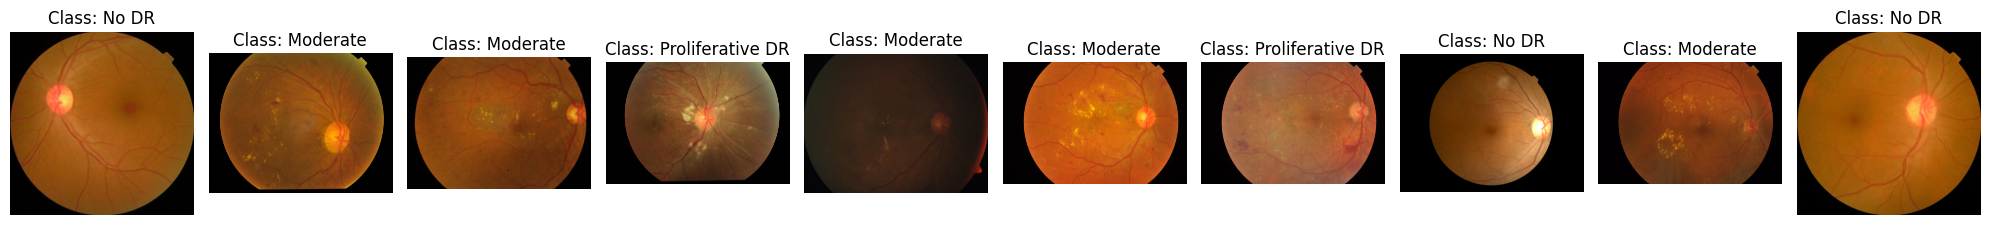

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from keras.models import Model
from keras import optimizers, applications
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import cv2
import matplotlib.image as mpimg

warnings.filterwarnings("ignore")
# Load the CSV files
train_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv")
valid_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv")
test_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/test.csv")

# Print the number of samples in each dataset
print('Number of train samples:', train_data.shape[0])
print('Number of validation samples:', valid_data.shape[0])
print('Number of test samples:', test_data.shape[0])


import os

# Define the image directories
train_image_dir = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images"
val_image_dir = "/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images"
test_image_dir = "/kaggle/input/datasets/mariaherrerot/aptos2019/test_images/test_images"

# Function to count images in a directory
def count_images(directory):
    return len([file for file in os.listdir(directory) if file.endswith(('.png', '.jpg', '.jpeg'))])

# Count images in each directory
train_image_count = count_images(train_image_dir)
val_image_count = count_images(val_image_dir)
test_image_count = count_images(test_image_dir)

# Print the counts
print(f'There are {train_image_count} training images.')
print(f'There are {val_image_count} validation images.')
print(f'There are {test_image_count} test images.')


import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg

# Class labels dictionary
class_labels = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# Check some random images from the training set to ensure they are correctly labeled
random_samples = random.sample(list(train_data['id_code']), 10)

plt.figure(figsize=(20, 10))
for i, image_id in enumerate(random_samples):
    # Image file path
    img_path = os.path.join(train_image_dir, f"{image_id}.png")  # Adjust extension if necessary
    img = mpimg.imread(img_path)
    
    # Get the class label for the image
    image_class = train_data.loc[train_data['id_code'] == image_id, 'diagnosis'].values[0]
    class_name = class_labels.get(image_class, "Unknown")
    
    # Plot the image
    plt.subplot(1, 10, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Class: {class_name}")

plt.tight_layout()
plt.show()

# 2. Class Distribution Analysis



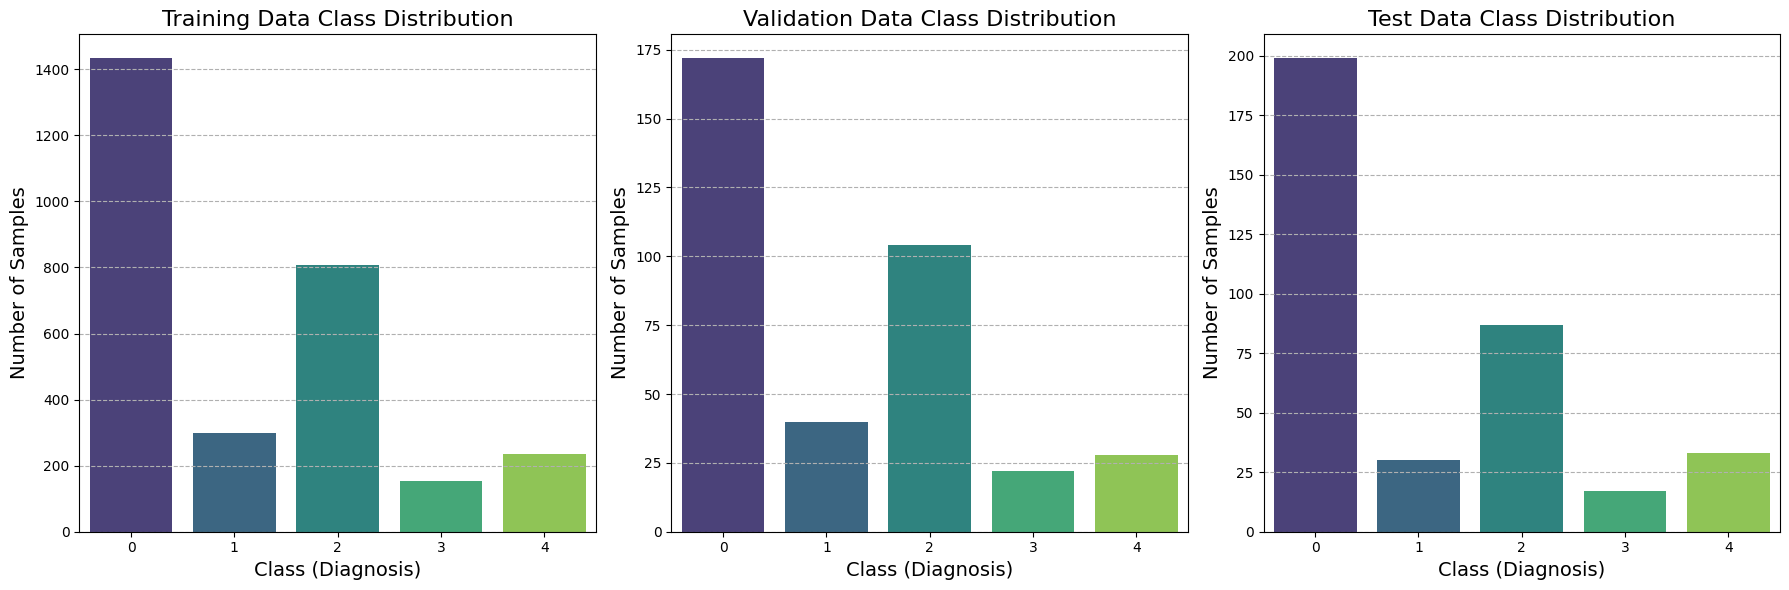

Training Data Class Distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Validation Data Class Distribution:
diagnosis
0    172
1     40
2    104
3     22
4     28
Name: count, dtype: int64

Test Data Class Distribution:
diagnosis
0    199
1     30
2     87
3     17
4     33
Name: count, dtype: int64


In [2]:
# ============================================================
# 2. CLASS DISTRIBUTION ANALYSIS
# Visualize the distribution of diagnosis classes across the datasets.
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the CSV files (if not already loaded)
train_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv")
valid_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv")
test_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/test.csv")

# Count the occurrences of each class in the training, validation, and test datasets
train_class_counts = train_data['diagnosis'].value_counts().sort_index()
val_class_counts = valid_data['diagnosis'].value_counts().sort_index()
test_class_counts = test_data['diagnosis'].value_counts().sort_index()

# Set up the bar charts for each dataset
plt.figure(figsize=(18, 6))

# Training Data
plt.subplot(1, 3, 1)
sns.barplot(x=train_class_counts.index, y=train_class_counts.values, palette='viridis')
plt.title('Training Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=train_class_counts.index, labels=train_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Validation Data
plt.subplot(1, 3, 2)
sns.barplot(x=val_class_counts.index, y=val_class_counts.values, palette='viridis')
plt.title('Validation Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=val_class_counts.index, labels=val_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Test Data
plt.subplot(1, 3, 3)
sns.barplot(x=test_class_counts.index, y=test_class_counts.values, palette='viridis')
plt.title('Test Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=test_class_counts.index, labels=test_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Print the number of samples for each class in the training data
print("Training Data Class Distribution:")
print(train_class_counts)
print("\nValidation Data Class Distribution:")
print(val_class_counts)
print("\nTest Data Class Distribution:")
print(test_class_counts)


# 3. Install SMOTE Dependency



In [3]:
# ============================================================
# 3. INSTALL SMOTE DEPENDENCY
# Install imbalanced-learn so that SMOTE can be used later.
# ============================================================
!pip install imbalanced-learn


# 4. Image Preprocessing, SMOTE & Data Split



In [4]:
# ============================================================
# 4. IMAGE PREPROCESSING, SMOTE AND DATA SPLIT
# Load and normalize retinal images, balance classes with SMOTE,
# restore image dimensions, one-hot encode labels, and split the data.
# ============================================================
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

# Define image dimensions and paths
IMG_SIZE = 100
train_image_dir = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images"

# Load CSV file
train_data = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv")

# Preprocess the images (this function remains unchanged)
def load_and_preprocess_image(image_id):
    img_path = os.path.join(train_image_dir, f"{image_id}.png")
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    return img_array

# Convert labels to numeric format and prepare features
X = np.array([load_and_preprocess_image(image_id) for image_id in train_data['id_code']])
y = train_data['diagnosis'].values

# Apply SMOTE to the labels
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X.reshape(X.shape[0], -1), y)  # Flatten images for SMOTE

# Convert back to the original image shape
X_resampled = X_resampled.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

# Convert labels to one-hot encoded format
y_resampled = to_categorical(y_resampled, num_classes=5)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


Shape of X_train: (5736, 100, 100, 3)
Shape of y_train: (5736, 5)


# 5. CNN Model Definition & Training



In [5]:
# ============================================================
# 5. CNN MODEL DEFINITION AND TRAINING
# Define the convolutional neural network and configure its training.
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    Callback,
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)


# ============================================================
# CNN MODEL
# ============================================================

def create_cnn_model(input_shape):

    model = Sequential()

    model.add(
        Conv2D(
            32,
            (3, 3),
            activation="relu",
            input_shape=input_shape
        )
    )
    model.add(
        MaxPooling2D(
            pool_size=(2, 2)
        )
    )

    model.add(
        Conv2D(
            64,
            (3, 3),
            activation="relu"
        )
    )
    model.add(
        MaxPooling2D(
            pool_size=(2, 2)
        )
    )

    model.add(
        Conv2D(
            128,
            (3, 3),
            activation="relu"
        )
    )
    model.add(
        MaxPooling2D(
            pool_size=(2, 2)
        )
    )

    model.add(
        Flatten()
    )

    model.add(
        Dense(
            128,
            activation="relu"
        )
    )

    model.add(
        Dropout(0.5)
    )

    model.add(
        Dense(
            5,
            activation="softmax"
        )
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

model = create_cnn_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


# ============================================================
# COMPILE
# ============================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]


# ============================================================
# DETAILED VALIDATION CALLBACK
# ============================================================

class DetailedMetricsCallback(Callback):

    def __init__(
        self,
        x_val,
        y_val,
        class_names
    ):
        super().__init__()

        self.x_val = x_val
        self.y_val = y_val
        self.class_names = class_names

        self.best_qwk = -np.inf
        self.best_epoch = 0

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        logs = logs or {}

        epoch_number = epoch + 1

        # ----------------------------------------------------
        # Validation predictions
        # ----------------------------------------------------

        probabilities = self.model.predict(
            self.x_val,
            verbose=0
        )

        y_pred = np.argmax(
            probabilities,
            axis=1
        )

        # ----------------------------------------------------
        # Convert validation labels
        # ----------------------------------------------------

        if len(self.y_val.shape) > 1:

            y_true = np.argmax(
                self.y_val,
                axis=1
            )

        else:

            y_true = self.y_val.astype(
                np.int64
            )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average="weighted",
            zero_division=0
        )

        qwk = cohen_kappa_score(
            y_true,
            y_pred,
            weights="quadratic"
        )

        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(5))
        )

        # ----------------------------------------------------
        # Per-class metrics
        # ----------------------------------------------------

        class_precision = precision_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average=None,
            zero_division=0
        )

        class_recall = recall_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average=None,
            zero_division=0
        )

        class_f1 = f1_score(
            y_true,
            y_pred,
            labels=list(range(5)),
            average=None,
            zero_division=0
        )

        # ====================================================
        # PRINT EPOCH
        # ====================================================

        print("\n")
        print("=" * 90)
        print(
            f"EPOCH {epoch_number:02d}"
        )
        print("=" * 90)

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------

        print(
            f"TRAIN"
        )

        print(
            f"Loss      : "
            f"{logs.get('loss', 0):.4f}"
        )

        print(
            f"Accuracy  : "
            f"{logs.get('accuracy', 0):.4f}"
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        print(
            "\nVALIDATION"
        )

        print(
            f"Loss              : "
            f"{logs.get('val_loss', 0):.4f}"
        )

        print(
            f"Accuracy          : "
            f"{accuracy:.4f}"
        )

        print(
            f"QWK               : "
            f"{qwk:.4f}"
        )

        print(
            f"Balanced Accuracy : "
            f"{balanced_acc:.4f}"
        )

        print(
            f"Macro Precision   : "
            f"{precision:.4f}"
        )

        print(
            f"Macro Recall      : "
            f"{recall:.4f}"
        )

        print(
            f"Macro F1          : "
            f"{macro_f1:.4f}"
        )

        print(
            f"Weighted F1       : "
            f"{weighted_f1:.4f}"
        )

        # ====================================================
        # PER-CLASS
        # ====================================================

        print("\nPER-CLASS METRICS")

        for i, name in enumerate(
            self.class_names
        ):

            print(
                f"C{i} - {name:18s} | "
                f"Precision: {class_precision[i]:.3f} | "
                f"Recall: {class_recall[i]:.3f} | "
                f"F1: {class_f1[i]:.3f}"
            )

        # ====================================================
        # CONFUSION MATRIX
        # ====================================================

        print(
            "\nCONFUSION MATRIX"
        )

        print(
            "Rows = True | Columns = Predicted"
        )

        print(
            f"{'':8s}"
            + "".join(
                f"C{i:^10}"
                for i in range(5)
            )
        )

        for i in range(5):

            print(
                f"C{i:<7}"
                + "".join(
                    f"{cm[i, j]:^10}"
                    for j in range(5)
                )
            )

        # ====================================================
        # CLASS DISTRIBUTION
        # ====================================================

        true_counts = np.bincount(
            y_true,
            minlength=5
        )

        pred_counts = np.bincount(
            y_pred,
            minlength=5
        )

        print(
            "\nVALIDATION CLASS DISTRIBUTION"
        )

        print(
            f"{'Class':20s}"
            f"{'True':>10s}"
            f"{'Predicted':>12s}"
            f"{'Delta':>10s}"
        )

        for i, name in enumerate(
            self.class_names
        ):

            delta = (
                pred_counts[i]
                - true_counts[i]
            )

            print(
                f"C{i} - {name:15s}"
                f"{true_counts[i]:>10}"
                f"{pred_counts[i]:>12}"
                f"{delta:>10}"
            )

        # ====================================================
        # CLASSIFICATION REPORT
        # ====================================================

        print(
            "\nCLASSIFICATION REPORT"
        )

        print(
            classification_report(
                y_true,
                y_pred,
                labels=list(range(5)),
                target_names=self.class_names,
                digits=4,
                zero_division=0
            )
        )

        # ====================================================
        # BEST QWK
        # ====================================================

        if (
            np.isfinite(qwk)
            and qwk > self.best_qwk
        ):

            self.best_qwk = qwk
            self.best_epoch = epoch_number

            print(
                f"★ NEW BEST QWK: "
                f"{qwk:.4f}"
            )

        else:

            print(
                f"Best QWK so far: "
                f"{self.best_qwk:.4f} "
                f"(epoch {self.best_epoch})"
            )

        print("=" * 90)


# ============================================================
# CALLBACKS
# ============================================================

detailed_metrics = DetailedMetricsCallback(
    x_val=X_val,
    y_val=y_val,
    class_names=CLASS_NAMES
)


callbacks = [

    detailed_metrics,

    EarlyStopping(
        patience=15,
        monitor="val_accuracy",
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model.keras",
        save_best_only=True,
        monitor="val_accuracy",
        verbose=1
    )
]


# ============================================================
# TRAIN
# ============================================================

print("=" * 90)
print("APTOS CNN TRAINING")
print("=" * 90)

print(
    f"Input size : {IMG_SIZE} × {IMG_SIZE}"
)

print(
    f"Classes    : {len(CLASS_NAMES)}"
)

print(
    f"Epochs     : 40"
)

print(
    f"Batch size : 32"
)

print(
    f"Device     : {tf.config.list_physical_devices('GPU')}"
)

print("=" * 90)


history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("TRAINING FINISHED")
print("=" * 90)

print(
    f"Best QWK   : "
    f"{detailed_metrics.best_qwk:.4f}"
)

print(
    f"Best epoch : "
    f"{detailed_metrics.best_epoch}"
)

print(
    "Best model : best_model.keras"
)

print("=" * 90)



I0000 00:00:1788156662.021814      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


APTOS CNN TRAINING
Input size : 100 × 100
Classes    : 5
Epochs     : 40
Batch size : 32
Device     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/40
 19/180 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2525 - loss: 1.5985

I0000 00:00:1788156669.967263      86 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3926 - loss: 1.3944

EPOCH 01
TRAIN
Loss      : 1.2814
Accuracy  : 0.4559

VALIDATION
Loss              : 1.1300
Accuracy          : 0.5237
QWK               : 0.5299
Balanced Accuracy : 0.5149
Macro Precision   : 0.5461
Macro Recall      : 0.5149
Macro F1          : 0.4816
Weighted F1       : 0.4904

PER-CLASS METRICS
C0 - No DR              | Precision: 0.836 | Recall: 0.869 | F1: 0.853
C1 - Mild               | Precision: 0.447 | Recall: 0.705 | F1: 0.547
C2 - Moderate           | Precision: 0.594 | Recall: 0.069 | F1: 0.123
C3 - Severe             | Precision: 0.504 | Recall: 0.476 | F1: 0.490
C4 - Proliferative DR   | Precision: 0.349 | Recall: 0.456 | F1: 0.395

CONFUSION MATRIX
Rows = True | Columns = Predicted
        C    0     C    1     C    2     C    3     C    4     
C0         266        15        1         23        1     
C1          17       203        0         22        46    
C2          16        64        19

# 6. Training History Visualization



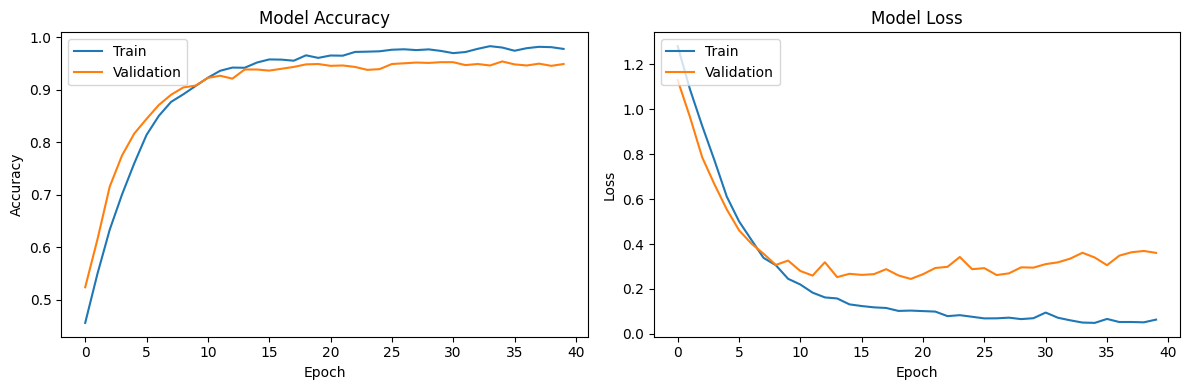

In [6]:
# ============================================================
# 6. TRAINING HISTORY VISUALIZATION
# Plot training and validation accuracy/loss across epochs.
# ============================================================
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


# 7. Validation Evaluation & Confusion Matrix



45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


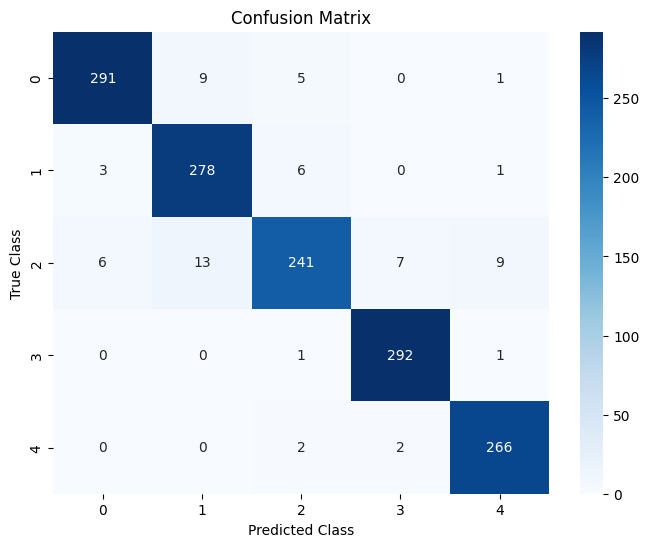

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.97      0.95      0.96       306
            Mild       0.93      0.97      0.95       288
        Moderate       0.95      0.87      0.91       276
          Severe       0.97      0.99      0.98       294
Proliferative DR       0.96      0.99      0.97       270

        accuracy                           0.95      1434
       macro avg       0.95      0.95      0.95      1434
    weighted avg       0.95      0.95      0.95      1434



In [7]:
# ============================================================
# 7. VALIDATION EVALUATION
# Generate predictions and evaluate the model using a confusion matrix
# and a classification report.
# ============================================================
# Predict the labels for the validation set
y_val_pred = model.predict(X_val)

# Convert one-hot encoded predictions and true labels back to class indices
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_val_true_classes, y_val_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# Generate the classification report
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
class_report = classification_report(y_val_true_classes, y_val_pred_classes, target_names=class_names)

print("Classification Report:")
print(class_report)

# 8. Additional SMOTE / Tabular Data Analysis



Initial train_data:
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0
Shape of train_data: (2930, 2)
Columns in train_data:
Index(['id_code', 'diagnosis'], dtype='object')
Shape of X_train: (2930, 1)
Shape of y_train: (2930,)


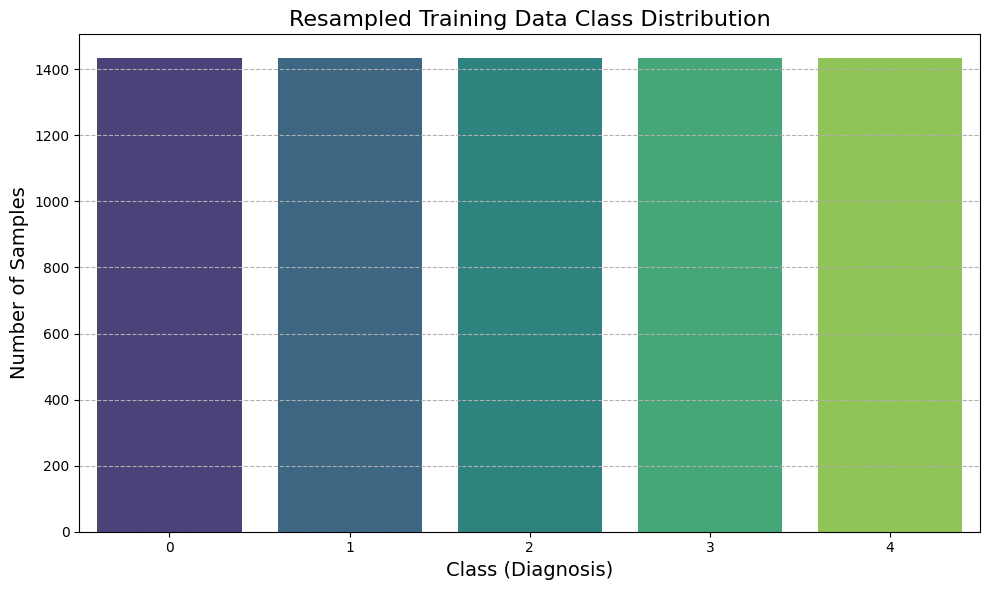

Resampled Training Data Class Distribution:
diagnosis
0    1434
1    1434
2    1434
3    1434
4    1434
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. ADDITIONAL SMOTE / TABULAR DATA ANALYSIS
# Inspect the training DataFrame and demonstrate SMOTE on its features.
# ============================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Check the initial DataFrame
print("Initial train_data:")
print(train_data.head())  # Display first few rows
print("Shape of train_data:", train_data.shape)

# Check the columns in train_data
print("Columns in train_data:")
print(train_data.columns)

# Encode 'id_code' using Label Encoding
label_encoder = LabelEncoder()
train_data['id_code'] = label_encoder.fit_transform(train_data['id_code'])

# Split features and labels from the training data
try:
    # Keep 'id_code' as a feature
    X_train = train_data.drop(columns=['diagnosis'])
    y_train = train_data['diagnosis']

    # Check the shapes of X_train and y_train
    print("Shape of X_train:", X_train.shape)
    print("Shape of y_train:", y_train.shape)

    # Initialize SMOTE
    smote = SMOTE(random_state=42)

    # Apply SMOTE to the training dataset
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Convert the resampled data back to a DataFrame
    resampled_train_data = pd.DataFrame(X_resampled, columns=X_train.columns)
    resampled_train_data['diagnosis'] = y_resampled

    # Count the occurrences of each class in the resampled training dataset
    resampled_class_counts = resampled_train_data['diagnosis'].value_counts().sort_index()

    # Plot the resampled class distribution
    plt.figure(figsize=(10, 6))
    sns.barplot(x=resampled_class_counts.index, y=resampled_class_counts.values, palette='viridis')
    plt.title('Resampled Training Data Class Distribution', fontsize=16)
    plt.xlabel('Class (Diagnosis)', fontsize=14)
    plt.ylabel('Number of Samples', fontsize=14)
    plt.xticks(ticks=resampled_class_counts.index, labels=resampled_class_counts.index)
    plt.grid(axis='y', linestyle='--')

    # Show the plot
    plt.tight_layout()
    plt.show()

    # Print the number of samples for each class in the resampled training data
    print("Resampled Training Data Class Distribution:")
    print(resampled_class_counts)

except Exception as e:
    print("An error occurred:", e)
